In [3]:
from pathlib import Path
import sys

# 当前 notebook 所在目录
NOTEBOOK_DIR = Path.cwd()

# 项目根目录
PROJECT_ROOT = NOTEBOOK_DIR.parent

# src 目录
SRC_DIR = PROJECT_ROOT / "src"

print("Notebook:", NOTEBOOK_DIR)
print("Project :", PROJECT_ROOT)
print("Src     :", SRC_DIR)

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

Notebook: /Users/baturu/Desktop/cv_software/notebooks
Project : /Users/baturu/Desktop/cv_software
Src     : /Users/baturu/Desktop/cv_software/src


In [4]:
import sys

print(sys.path[0])

/Users/baturu/Desktop/cv_software/src


In [11]:
from pathlib import Path
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd
from data.build_labels import build_labels
from models.mouseDataset import MouseDataset
from training.training import *
from evaluation.experiment import *
from visualization.saliency_map import *
from evaluation.experiment_modified import *
from visualization.visualization_functions import *
from visualization.gradcam_functions import visualize_gradcam


In [12]:
PROJECT_DIR = Path.cwd()

BASE_DIR = PROJECT_DIR / "mouse_dataset"
IMG_DIR = BASE_DIR / "images_perfect"

MGS_CSV = BASE_DIR / "MouseGrimaceFaces_mgs.csv"
MAIN_CSV = BASE_DIR / "MouseGrimaceFaces_main.csv"

# 02 Muzzle-only Classification

这个 notebook 使用 `mouse_dataset/muzzle_crops` 里面已经裁剪好的 muzzle 图片来训练分类模型。  
核心逻辑和 full-image classification 相同，区别是：

- full image classification 读取 `mouse_dataset/images`
- muzzle-only classification 读取 `mouse_dataset/muzzle_crops`
- 只保留已经成功 crop 的图片

## select impared images & save (optional)

In [ ]:
from build_labels import copy_impaired_images

df = build_labels(
    MGS_CSV,
    MAIN_CSV,
    IMG_DIR
)

copy_impaired_images(
    df,
    "mouse_dataset/image_impaired"
)

## sample visualization (option)

In [ ]:
# 当前已分配的内存torch.mps.empty_cache()
print(f"已分配内存: {torch.mps.current_allocated_memory() / 1024**3:.2f} GiB")
# 驱动程序分配的总内存
print(f"驱动分配总量: {torch.mps.driver_allocated_memory() / 1024**3:.2f} GiB")

print("Current directory:", PROJECT_DIR)
print("Dataset path:", BASE_DIR)
print("MGS exists:", MGS_CSV.exists())
print("MAIN exists:", MAIN_CSV.exists())
print("Muzzle crop folder exists:", IMG_DIR.exists())
print("Number of crop images:", len(list(IMG_DIR.glob("*.jpg"))) + len(list(IMG_DIR.glob("*.png"))))


print("Total usable muzzle-crop images:", len(df))
print("Label distribution:")
print(df["label"].value_counts())

print("Subset distribution:")
print(df["subset"].value_counts())

df.head()


In [ ]:
# Optional: visualize random muzzle crops before training

sample_df = df.sample(n=min(25, len(df)), random_state=42)

plt.figure(figsize=(12, 12))

for i, (_, row) in enumerate(sample_df.iterrows()):
    img = Image.open(row["path"]).convert("RGB")
    plt.subplot(5, 5, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f'{row["index"]}label={row["label"]}', fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
print("Train size:", len(train_df))
print("Validation size:", len(val_df))

print("Train label distribution:")
print(train_df["label"].value_counts())

print("Validation label distribution:")
print(val_df["label"].value_counts())

In [ ]:
model, history = run_training(
    train_df=train_df,
    val_df=val_df,
    dataset_class=MouseDataset,
    train_one_epoch_fn=train_one_epoch,
    evaluate_fn=evaluate,
    save_path="mouse_wellbeing_convnext_tiny.pt",
    epochs=10,
    batch_size=50,
    lr=1e-4,
    weight_decay=1e-4
)

# use lr schedule

In [29]:
from pathlib import Path

# notebooks/
NOTEBOOK_DIR = Path.cwd()

# cv_software/
PROJECT_ROOT = NOTEBOOK_DIR.parent

BASE_DIR = PROJECT_ROOT / "data"
IMG_DIR = BASE_DIR / "images_perfect"

MGS_CSV = BASE_DIR / "MouseGrimaceFaces_mgs.csv"
MAIN_CSV = BASE_DIR / "MouseGrimaceFaces_main.csv"

In [32]:
print(NOTEBOOK_DIR.parent)

/Users/baturu/Desktop/cv_software


In [33]:
df = build_labels(MGS_CSV, MAIN_CSV, IMG_DIR)
# We split by mouse identity, not by individual image.
# This avoids putting images from the same mouse in both train and validation.
train_df, val_df = make_group_split(df)

Rows before crop filtering: 3406
Rows after crop filtering:  1398
Removed because crop image missing: 2008


In [37]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

OUTPUT_DIR = PROJECT_ROOT / "outputs"
MODEL_DIR = OUTPUT_DIR / "models"

# 如果不存在就自动创建
MODEL_DIR.mkdir(parents=True, exist_ok=True)

save_path = MODEL_DIR / "the_best_muzzle_image_model_v1.pt"


Using device: mps

Epoch 1/1
Current LR: 0.00001000


Validation: 100%|██████████| 29/29 [00:05<00:00,  5.34it/s]


Train loss: 0.6100816745311022
Validation macro_f1: 0.7657

Confusion matrix:
[[109  36]
 [ 31 110]]

Classification report:
              precision    recall  f1-score   support

  well-being       0.78      0.75      0.76       145
    impaired       0.75      0.78      0.77       141

    accuracy                           0.77       286
   macro avg       0.77      0.77      0.77       286
weighted avg       0.77      0.77      0.77       286

Saved best model to /Users/baturu/Desktop/cv_software/outputs/models/the_best_muzzle_image_model_v1.pt
New best model: epoch=1, macro_f1=0.7657

Loaded best model from epoch 1 with macro_f1=0.7657


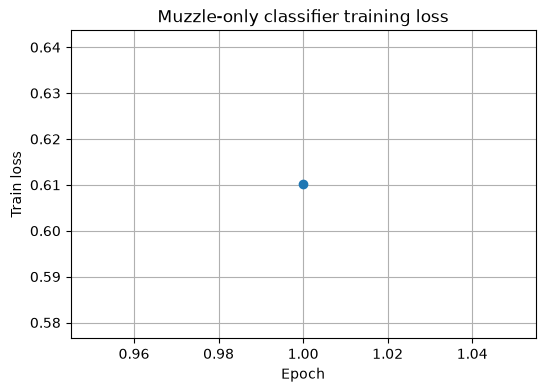

In [39]:
model, history = run_training_with_lr_schedule_early_stop_best_model(
    train_df=train_df,
    val_df=val_df,
    dataset_class=MouseDataset,
    train_one_epoch_fn=train_one_epoch,
    evaluate_fn=evaluate,
    save_path=save_path,
    epochs=1,
    batch_size=10,
    lr=1e-5,
    metric_name="macro_f1",
    scheduler_patience=2,
    early_stopping_patience=5
)

history_df = pd.DataFrame(history)

plt.figure(figsize=(6, 4))
plt.plot(history_df["epoch"], history_df["train_loss"], marker="o")
plt.xlabel("Epoch")
plt.ylabel("Train loss")
plt.title("Muzzle-only classifier training loss")
plt.grid(True)
plt.show()

## plotting

In [ ]:
from visualization_functions import visualize_binary_classifier_results

train_loader, val_loader = build_dataloaders(
    train_df=train_df,
    val_df=val_df,
    dataset_class=MouseDataset,
    batch_size=32,
    image_size=224
)

results = visualize_binary_classifier_results(
    model=model,
    val_loader=val_loader,
    evaluate_with_probs_fn=evaluate_with_probs,
    output_dir="output",
    prefix="muzzle_only",
    title_prefix="Muzzle Only"
)

## use grad cam saliency map

### 导入gradcam

In [ ]:
_, val_tfms = build_transforms()

visualize_gradcam(
    model=model,
    val_df=val_df,
    dataset_class=MouseDataset,
    target_layer=model.features[-1][-1].block[-1],
    output_dir="output/gradcam",
    num_images=5,
    transform=val_tfms
)

### 手搓grad cam

In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np


class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None

        self.forward_hook = target_layer.register_forward_hook(
            self.save_activation
        )
        self.backward_hook = target_layer.register_full_backward_hook(
            self.save_gradient
        )

    def save_activation(self, module, input, output):
        self.activations = output.detach()

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def __call__(self, img_tensor, device, target_class=None):
        self.model.eval()

        img = img_tensor.unsqueeze(0).to(device)
        output = self.model(img)

        pred_class = output.argmax(dim=1).item()

        if target_class is None:
            target_class = pred_class

        score = output[0, target_class]

        self.model.zero_grad()
        score.backward()

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1)

        cam = F.relu(cam)
        cam = cam.squeeze().cpu().numpy()

        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

        return cam, pred_class, target_class

    def remove_hooks(self):
        self.forward_hook.remove()
        self.backward_hook.remove()


def show_gradcam(
    model,
    dataset,
    index,
    device,
    gradcam,
    target_class=None,
    class_names=None
):
    if class_names is None:
        class_names = ["well-being", "impaired"]

    img_tensor, true_label = dataset[index]

    cam, pred_class, used_class = gradcam(
        img_tensor=img_tensor,
        device=device,
        target_class=target_class
    )

    img = denormalize(img_tensor)

    cam_resized = F.interpolate(
        torch.tensor(cam).unsqueeze(0).unsqueeze(0),
        size=img.shape[:2],
        mode="bilinear",
        align_corners=False
    ).squeeze().numpy()

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(img)
    plt.title(f"Original\nTrue: {class_names[int(true_label)]}")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(cam_resized, cmap="jet")
    plt.title(f"Grad-CAM\nClass: {class_names[used_class]}")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(img)
    plt.imshow(cam_resized, cmap="jet", alpha=0.45)
    plt.title(f"Overlay\nPred: {class_names[pred_class]}")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

In [ ]:
# ==========================
# Build validation dataset
# ==========================
device = get_device()
_, val_tfms = build_transforms()

val_ds = MouseDataset(
    val_df,
    transform=val_tfms
)

# ==========================
# Create GradCAM object
# ==========================

target_layer = model.features[-1][-1].block[-1]

gradcam = GradCAM(
    model=model,
    target_layer=target_layer
)

number_of_images_2_show = 50 
for idx in range(number_of_images_2_show):
    show_gradcam(
        model=model,
        dataset=val_ds,
        index=idx,
        device=device,
        gradcam=gradcam,
        target_class=None
    )

# Fullimage

In [ ]:
# folder where current script exists
PROJECT_DIR = Path.cwd()
BASE_DIR = PROJECT_DIR / "mouse_dataset"
IMG_DIR = BASE_DIR / "images_mgs"
MGS_CSV = BASE_DIR / "MouseGrimaceFaces_mgs.csv"
MAIN_CSV = BASE_DIR / "MouseGrimaceFaces_main.csv"

In [ ]:
df2 = build_labels(MGS_CSV, MAIN_CSV, IMG_DIR)
train_df2, val_df2 = make_group_split(df2)

In [ ]:
model2, history2 = run_training_with_lr_schedule_early_stop_best_model(
    train_df=train_df2,
    val_df=val_df2,
    dataset_class=MouseDataset,
    train_one_epoch_fn=train_one_epoch,
    evaluate_fn=evaluate,
    save_path="best_full_image_model.pt",
    epochs=5,
    batch_size=20,
    lr=1e-5,
    metric_name="macro_f1",
    scheduler_patience=2,
    early_stopping_patience=5
)

history_df = pd.DataFrame(history2)

plt.figure(figsize=(6, 4))
plt.plot(history_df["epoch"], history_df["train_loss"], marker="o")
plt.xlabel("Epoch")
plt.ylabel("Train loss")
plt.title("Muzzle-only classifier training loss")
plt.grid(True)
plt.show()

## plotting

In [ ]:
from visualization_functions import visualize_binary_classifier_results

train_loader2, val_loader2 = build_dataloaders(
    train_df=train_df,
    val_df=val_df,
    dataset_class=MouseDataset,
    batch_size=32,
    image_size=224
)

results = visualize_binary_classifier_results(
    model=model2,
    val_loader=val_loader2,
    evaluate_with_probs_fn=evaluate_with_probs,
    output_dir="output",
    prefix="full_image",
    title_prefix="full_image"
)

## grad cam

In [ ]:
_, val_tfms = build_transforms()

visualize_gradcam(
    model=model2,
    val_df=val_df2,
    dataset_class=MouseDataset,
    target_layer=model2.features[-1][-1].block[-1],
    output_dir="output/gradcam",
    num_images=5,
    transform=val_tfms
)